# Convolutional Neural Networks (CNNs): Theory and Examples

This notebook provides a comprehensive introduction to Convolutional Neural Networks and we plan to cover both theoretical concepts and practical examples as we do in lectures.

## Table of Contents
1. [Introduction to CNNs](#introduction)
2. [Convolution Operation](#convolution)
4. [Activation Functions](#activation)
5. [Building a Complete CNN](#complete-cnn)
6. [Training and Evaluation](#training)

By Tanmay Raswant and Jonathan Qunell


## 1. Introduction to CNNs <a id="introduction"></a>

**Convolutional Neural Networks (CNNs)** are a specialized type of neural network designed for processing grid-like data, particularly images. They are highly effective for image recognition, classification, and computer vision tasks. A very famous example which we will cover is of MNIST data set.

### Key Advantages of CNNs:
- **Parameter Sharing**: The same filter is applied across the entire image, reducing the number of parameters
- **Translation Invariance**: CNNs can detect features regardless of their position in the image
- **Hierarchical Feature Learning**: Lower layers detect simple features (edges, corners), while deeper layers detect complex patterns (shapes, objects)

### Basic Architecture:
1. **Convolutional Layers**: Apply filters to detect features
2. **Activation Functions**: Introduce non-linearity
3. **Pooling Layers**: Reduce spatial dimensions
4. **Fully Connected Layers**: Final classification/regression


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import seaborn as sns

np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Convolution Operation <a id="convolution"></a>

The **convolution operation** is the fundamental building block of CNNs. It involves sliding a small filter (kernel) over the input and computing the dot product at each position. Convolution can be applied in 1D, 2D, or even 3D, depending on the data type.

### 1D Convolution

**1D convolution** is used for sequential data like time series, audio signals, or text sequences.

#### Mathematical Definition:
For a 1D convolution:
$$(f * g)(i) = \sum_{m} f(m) \cdot g(i-m)$$

Where:
- $f$ is the input sequence (1D array)
- $g$ is the filter/kernel (1D array)
- $*$ denotes convolution

**Applications:**
- Time series analysis (stock prices)
- Audio signal processing

#### Example:
![Image 1](images/udl-10.2.png)

If you want to access $z_1$ and $z_6$, you need to use 0 padding





![Image 2](images/udl-10.3.png)

![Image 3](images/udl-10.5.png)

from Understanding deep learning by Simon Prince

### 2D Convolution

**2D convolution** is used for images and 2D spatial data (most common in CNNs for computer vision).

#### Mathematical Definition:
For a 2D convolution:
$$(f * g)(i, j) = \sum_{m} \sum_{n} f(m, n) \cdot g(i-m, j-n)$$

Where:
- $f$ is the input image (2D array)
- $g$ is the filter/kernel (2D matrix)
- $*$ denotes convolution

#### Example:
- **Input**: 28×28 image (MNIST digit)
- **Kernel**: 3×3 filter (edge detection, blur, etc.)
- **Output**: Feature map showing detected patterns

**Applications:**
- Image classification
- Object detection
- Medical imaging
- Satellite image analysis

### Key Concepts (Common to Both):
- **Filter/Kernel**: A small array/matrix that detects specific features
  - 1D: Typically 3, 5, or 7 elements
  - 2D: Typically 3×3 or 5×5
- **Stride**: How many positions the filter moves at each step
- **Padding**: Adding zeros around the input to control output size
- **Feature Map**: The output of applying a filter to the input
- **Channels**: Multiple filters can be applied simultaneously, creating multiple feature maps


### Example 1: Understanding Convolution with Different Kernels

The convolution operation can be visualized as a kernel sliding over an image. Different kernels detect different features:

#### Visual Example: Edge Detection

**Original Image with Vertical Line:**
![Original Image](images/original_image.png)

**Vertical Edge Detection Kernel:**
```
[-1  0  1]
[-1  0  1]
[-1  0  1]
```
This kernel detects vertical edges by computing the difference between left and right pixels.

**Result:** Strong response where vertical edges are present
![Vertical Edge Detection](images/vertical_edges.png)

**Horizontal Edge Detection Kernel:**
```
[-1 -1 -1]
[ 0  0  0]
[ 1  1  1]
```
This kernel detects horizontal edges by computing the difference between top and bottom pixels.

**Result:** Weak response for vertical lines (as expected)
![Horizontal Edge Detection](images/horizontal_edges.png)

**Blur/Averaging Kernel:**
```
[1/9  1/9  1/9]
[1/9  1/9  1/9]
[1/9  1/9  1/9]
```
This kernel smooths the image by averaging neighboring pixels.

**Result:** Smoothed version of the original image
![Blurred Image](images/blurred_image.png)

**Complete Comparison:**
![Convolution Comparison](images/convolution_comparison.png)

#### Key Observations:
- **Vertical edge kernel** produces strong responses (high values) where vertical lines exist
- **Horizontal edge kernel** produces weak responses for vertical lines, as it's designed to detect horizontal features
- **Blur kernel** smooths the image, reducing sharp transitions
- Each kernel acts as a **feature detector** - this is the fundamental principle of CNNs!





#### Understanding the Vertical Edge Detection Pattern

You might be wondering: **Why does the vertical edge detection show grey → white → black → grey?**

Let's break down exactly what happens when the vertical edge detection kernel slides over our image:

**The Vertical Edge Detection Kernel:**
```
[-1  0  1]
[-1  0  1]
[-1  0  1]
```

This kernel computes: **Right pixels - Left pixels** (multiplied by -1 on left, +1 on right)

**Our Original Image:**
- Columns 0-2: Black (value = 0)
- Columns 3-4: White (value = 1) ← This is our vertical line
- Columns 5-7: Black (value = 0)

**Step-by-Step: What happens as the kernel slides across?**

1. **Position 1: Kernel entirely on the left (before the line)**
   - Left pixels: 0, Right pixels: 0
   - Calculation: (0 × -1) + (0 × 0) + (0 × 1) = 0
   - **Result: Grey/Black (value ≈ 0)**

2. **Position 2: Kernel crossing INTO the line (left edge)**
   - Left pixels: 0, Right pixels: 1
   - Calculation: (0 × -1) + (0 × 0) + (1 × 1) = **+1** (or +3 when summing all 3 rows)
   - **Result: WHITE (positive value)** ← This detects the left edge!

3. **Position 3: Kernel entirely on the line**
   - Left pixels: 1, Right pixels: 1
   - Calculation: (1 × -1) + (1 × 0) + (1 × 1) = 0
   - **Result: Grey/Black (value ≈ 0)** ← No edge here, it's uniform

4. **Position 4: Kernel crossing OUT of the line (right edge)**
   - Left pixels: 1, Right pixels: 0
   - Calculation: (1 × -1) + (1 × 0) + (0 × 1) = **-1** (or -3 when summing all 3 rows)
   - **Result: BLACK (negative value)** ← This detects the right edge!

5. **Position 5: Kernel entirely on the right (after the line)**
   - Left pixels: 0, Right pixels: 0
   - Calculation: (0 × -1) + (0 × 0) + (0 × 1) = 0
   - **Result: Grey/Black (value ≈ 0)**

**Visual Summary:**
```
Original:  [0 0 0 | 1 1 | 0 0 0]
           ←─────┘     └─────→
           Left side   Right side

Result:    [0 0    | +3 |    0    | -3 |   0 0]
           Grey    White   Grey    Black  Grey
```

**Key Insight:**
- **White regions** = Positive values = Detected a transition from dark to light (left edge)
- **Black regions** = Negative values = Detected a transition from light to dark (right edge)
- **Grey regions** = Zero values = No edge detected (uniform region)

The kernel is specifically designed to detect **vertical edges** by measuring the difference between left and right pixels. When displayed as an image, positive values appear white, negative values appear black, and zeros appear grey!


## 3. Activation Functions <a id="activation"></a>

**Activation functions** introduce non-linearity into neural networks, allowing them to learn complex patterns. Without activation functions, a neural network would just be a linear transformation.

### Common Activation Functions in CNNs:

1. **ReLU (Rectified Linear Unit)**: $f(x) = \max(0, x)$
   - Most common in CNNs
   - Simple and computationally efficient
   - Addresses vanishing gradient problem
   
2. **Sigmoid**: $f(x) = \frac{1}{1 + e^{-x}}$
   - Outputs values between 0 and 1
   - Used in output layer for binary classification
   
3. **Tanh**: $f(x) = \tanh(x)$
   - Outputs values between -1 and 1
   - Sometimes used in hidden layers

4. **Softmax**: $f(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}$
   - Used in output layer for multi-class classification
   - Converts logits to probabilities


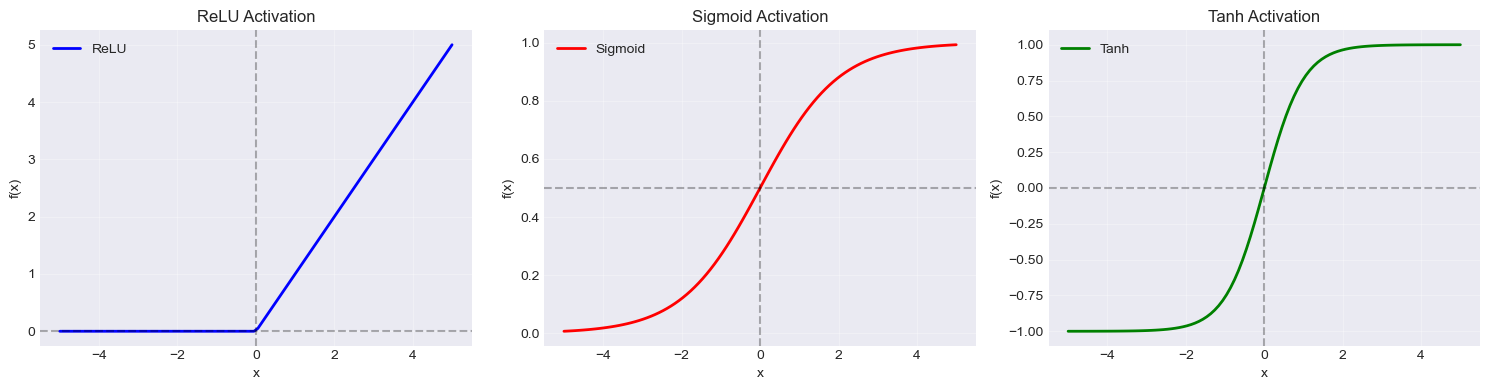

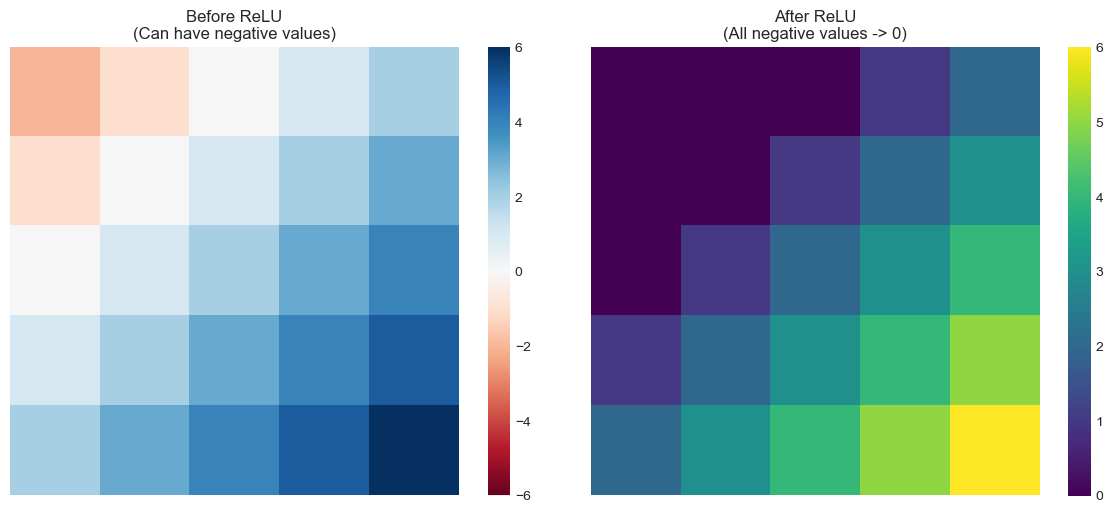

ReLU sets all negative values to zero, introducing non linearity


In [54]:
x = np.linspace(-5, 5, 100)

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

y_relu = relu(x)
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, y_relu, 'b-', linewidth=2, label='ReLU')
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_title('ReLU Activation', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, y_sigmoid, 'r-', linewidth=2, label='Sigmoid')
axes[1].axhline(y=0.5, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_title('Sigmoid Activation', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(x, y_tanh, 'g-', linewidth=2, label='Tanh')
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[2].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[2].set_title('Tanh Activation', fontsize=12)
axes[2].set_xlabel('x')
axes[2].set_ylabel('f(x)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

feature_map_with_negatives = np.array([[-2, -1, 0, 1, 2],
                                       [-1, 0, 1, 2, 3],
                                       [0, 1, 2, 3, 4],
                                       [1, 2, 3, 4, 5],
                                       [2, 3, 4, 5, 6]])

relu_applied = relu(feature_map_with_negatives)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(feature_map_with_negatives, cmap='RdBu', vmin=-6, vmax=6)
axes[0].set_title('Before ReLU\n(Can have negative values)', fontsize=12)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(relu_applied, cmap='viridis', vmin=0, vmax=6)
axes[1].set_title('After ReLU\n(All negative values -> 0)', fontsize=12)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("ReLU sets all negative values to zero, introducing non linearity")


## 4. Building a Complete CNN <a id="complete-cnn"></a>

Now let's combine all these concepts to build a complete CNN architecture. A typical CNN consists of:

1. **Convolutional blocks**: Conv → Activation
2. **Fully connected layers**: For final classification
3. **Dropout**: Regularization technique to prevent overfitting

### Our CNN Architecture:
```
Input Image
    ↓
Conv2d → ReLU
    ↓
Conv2d → ReLU
    ↓
Conv2d → ReLU
    ↓
Flatten
    ↓
Linear → ReLU → Dropout
    ↓
Linear → Softmax
    ↓
Output (Class Probabilities)
```


In [ ]:
# Example 5: Building a Simple CNN from Scratch

class SimpleCNN(nn.Module):
    """
    A simple CNN for image classification.
    Architecture:
    - Conv Block 1: Conv → ReLU
    - Conv Block 2: Conv → ReLU
    - Conv Block 3: Conv → ReLU
    - Fully Connected: Linear → ReLU → Dropout → Linear
    """
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Fully connected layers
        # With padding=1, image size stays 28x28 through all conv layers
        # So for 28x28 input: 28x28x64 = 50,176 features
        self.fc1 = nn.Linear(28 * 28 * 64, 128) #64 is out channels from conv3 and 128 is number of neurons in the first fully connected layer
        
        # Dropout Layer: Regularization technique to prevent overfitting
        # What does Dropout(0.5) do?
        #   - During training: Randomly sets 50% (0.5) of neurons to zero
        #   - Forces the network to not rely on any single neuron
        #   - Prevents overfitting (memorizing training data instead of learning patterns)
        #   - During inference/testing: All neurons are used (no dropout)
        # Why 0.5? Common choice (50% dropout rate). Could be 0.3, 0.4, 0.6, etc.
        self.dropout = nn.Dropout(0.5)
        
        # Final Classification Layer: Maps features to class predictions
        # Input: 128 neurons (from fc1)
        # Output: num_classes neurons (10 for MNIST: digits 0-9)
        # Each output neuron represents the "score" or "logit" for one class
        # Example: [2.1, 0.3, -1.2, 5.4, ...] means the model thinks it's class 3 (highest score)
        # After softmax: converts these scores to probabilities that sum to 1.0
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        """
        Forward pass: transforms input image through the network to get class predictions.
        
        Input: x has shape (batch_size, 1, 28, 28) - batch of grayscale images
        Output: x has shape (batch_size, 10) - class scores/logits for each image
        """
        
        # Apply first convolution: detects simple features (edges, corners)
        x = self.conv1(x)  # Shape: (batch, 16, 28, 28)
        x = F.relu(x)  #Sets negative values to 0 and introduces non linearity
        
        # Apply second convolution: detects intermediate patterns
        x = self.conv2(x)  # Shape: (batch, 32, 28, 28)
        #   Input: 16 channels from conv1
        #   Output: 32 feature maps (more complex patterns)
        x = F.relu(x)
        
        # Apply third convolution: detects complex patterns
        x = self.conv3(x)  # Shape: (batch, 64, 28, 28)
        #   Input: 32 channels from conv2
        #   Output: 64 feature maps (very complex patterns, shapes, textures)
        x = F.relu(x)
        
        # Convert 3D feature maps to 1D vector for fully connected layers
        x = x.view(x.size(0), -1)  # Shape: (batch, 50176)
        #   x.size(0) = batch_size (keep batch dimension)
        #   -1 means "flatten everything else": 64 × 28 × 28 = 50,176
        #   Why? Fully connected layers need 1D input, not 3D
        
        # Combine all features into a smaller representation
        x = self.fc1(x)  # Shape: (batch, 128)
        #   Input: 50,176 features
        #   Output: 128 neurons (its a hyperparameter and can be changed)
        #   Learns which combinations of features are important
        
        x = F.relu(x)
        x = self.dropout(x)
        
        # Map features to class scores
        x = self.fc2(x)  # Shape: (batch, 10)
        #   Input: 128 features
        #   Output: 10 scores (one for each digit 0-9)
        #   These are "logits" (raw scores, not probabilities yet)
        #   Highest score = predicted class
        
        return x  # Return class scores/logits

model = SimpleCNN(num_classes=10)
print("CNN Architecture:")
print(model)
print("\n" + "="*50)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

dummy_input = torch.randn(1, 1, 28, 28)  # (batch=1, channels=1, height=28, width=28)
print(f"\nInput shape: {dummy_input.shape}")

with torch.no_grad():
    output = model(dummy_input)
    print(f"Output shape: {output.shape}")
    print(f"Output (logits): {output[0].numpy()}")

print("\n" + "="*50)
print("Data Flow Through the Network:")
print("="*50)
print("Input:        (1, 1, 28, 28)")
print("After Conv1:  (1, 16, 28, 28)  [padding=1 keeps size]")
print("After Conv2:  (1, 32, 28, 28)  [padding=1 keeps size]")
print("After Conv3:  (1, 64, 28, 28)  [padding=1 keeps size]")
print("After Flatten: (1, 50176)")
print("After FC1:    (1, 128)")
print("After FC2:    (1, 10)")


CNN Architecture:
SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Total parameters: 6,447,242
Trainable parameters: 6,447,242

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])
Output (logits): [-0.00563208  0.02900712 -0.01319725 -0.07126896  0.09127448 -0.01938305
  0.01040298  0.03829132  0.07445066 -0.01894506]

Data Flow Through the Network:
Input:        (1, 1, 28, 28)
After Conv1:  (1, 16, 28, 28)  [padding=1 keeps size]
After Conv2:  (1, 32, 28, 28)  [padding=1 keeps size]
After Conv3:  (1, 64, 28, 28)  [padding=1 keeps size]
After Flatten: (1, 50176)
After FC1:    (1, 128)
After FC2:    (1, 10)


Using device: cpu

Training samples: 60000
Test samples: 10000
Number of classes: 10


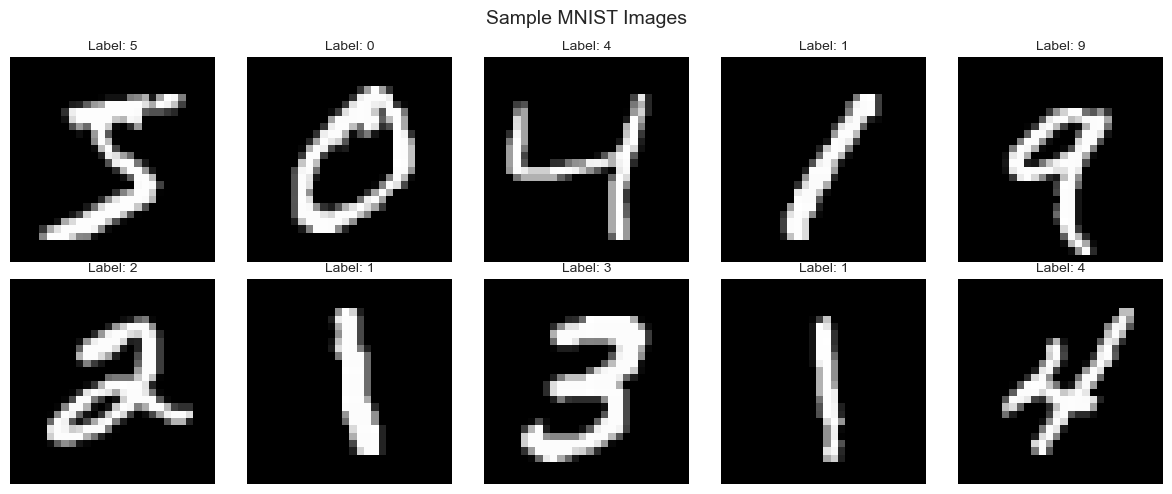

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {10}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = train_dataset[i]
    row, col = i // 5, i % 5
    axes[row, col].imshow(img.squeeze(), cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=10)
    axes[row, col].axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 100 == 0:
            print(f'  Batch [{batch_idx+1}/{len(train_loader)}], '
                  f'Loss: {loss.item():.4f}, '
                  f'Accuracy: {100 * correct / total:.2f}%')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

num_epochs = 3
train_losses, train_accs = [], []
test_losses, test_accs = [], []

print("Starting training...")
print("="*60)

for epoch in range(num_epochs):
    print(f'\nEpoch [{epoch+1}/{num_epochs}]')
    print('-' * 60)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f'\nEpoch [{epoch+1}/{num_epochs}] Summary:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

print("\n" + "="*60)
print("Training completed!")


Starting training...

Epoch [1/3]
------------------------------------------------------------
  Batch [100/938], Loss: 0.4596, Accuracy: 76.88%
  Batch [200/938], Loss: 0.2228, Accuracy: 84.35%
  Batch [300/938], Loss: 0.2144, Accuracy: 87.48%
  Batch [400/938], Loss: 0.0658, Accuracy: 89.52%
  Batch [500/938], Loss: 0.0581, Accuracy: 90.79%
  Batch [600/938], Loss: 0.1130, Accuracy: 91.62%
  Batch [700/938], Loss: 0.1408, Accuracy: 92.30%
  Batch [800/938], Loss: 0.0879, Accuracy: 92.88%
  Batch [900/938], Loss: 0.0746, Accuracy: 93.33%

Epoch [1/3] Summary:
  Train Loss: 0.2131, Train Acc: 93.49%
  Test Loss: 0.0470, Test Acc: 98.44%

Epoch [2/3]
------------------------------------------------------------
  Batch [100/938], Loss: 0.0547, Accuracy: 97.50%
  Batch [200/938], Loss: 0.2628, Accuracy: 97.51%
  Batch [300/938], Loss: 0.0160, Accuracy: 97.46%
  Batch [400/938], Loss: 0.0229, Accuracy: 97.45%
  Batch [500/938], Loss: 0.0466, Accuracy: 97.45%
  Batch [600/938], Loss: 0.0097

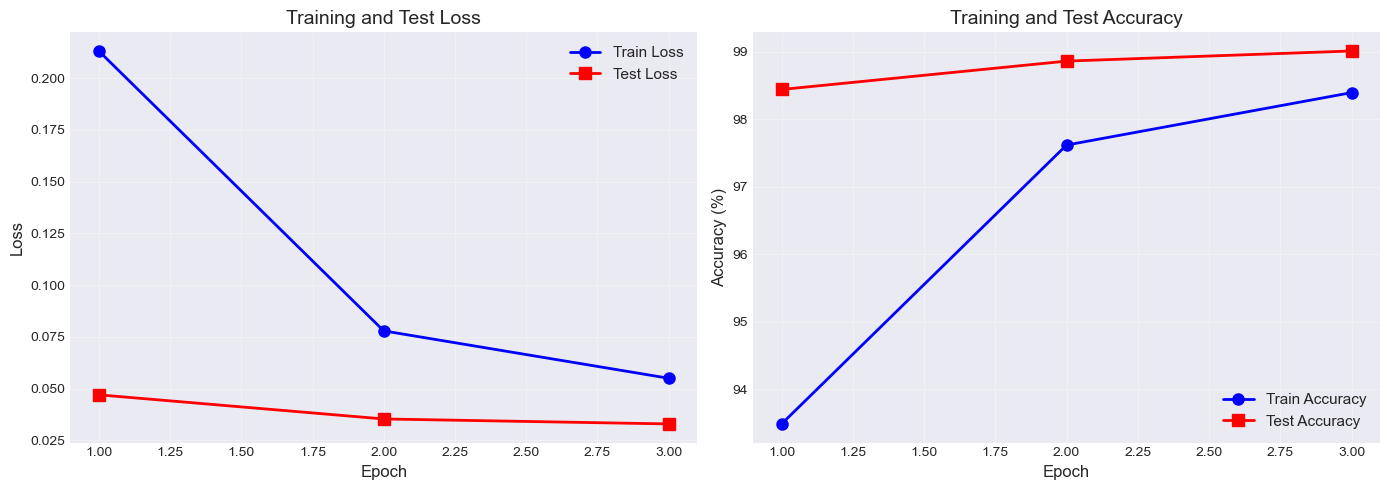

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, num_epochs+1), train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=8)
axes[0].plot(range(1, num_epochs+1), test_losses, 'r-s', label='Test Loss', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Test Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, num_epochs+1), train_accs, 'b-o', label='Train Accuracy', linewidth=2, markersize=8)
axes[1].plot(range(1, num_epochs+1), test_accs, 'r-s', label='Test Accuracy', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Test Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


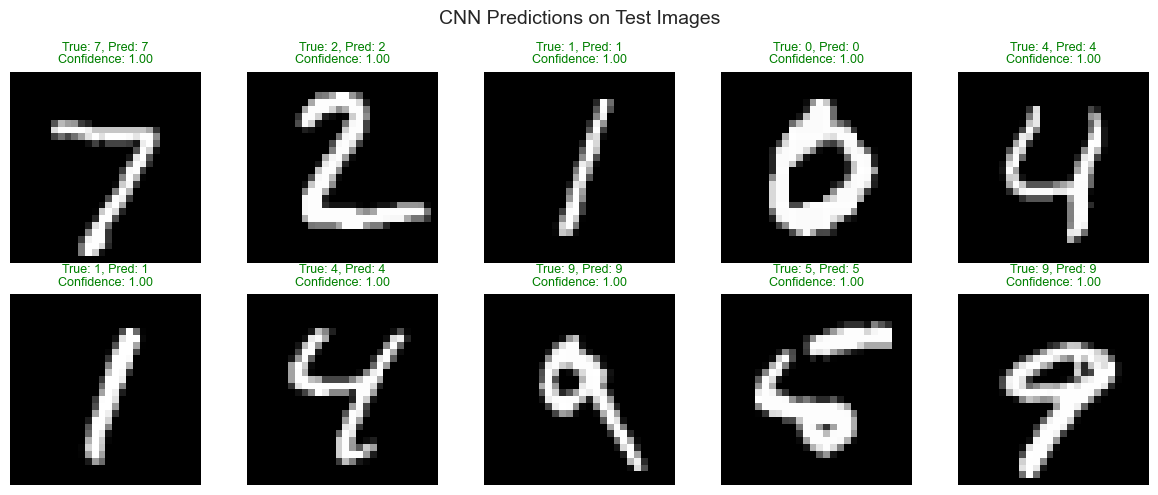

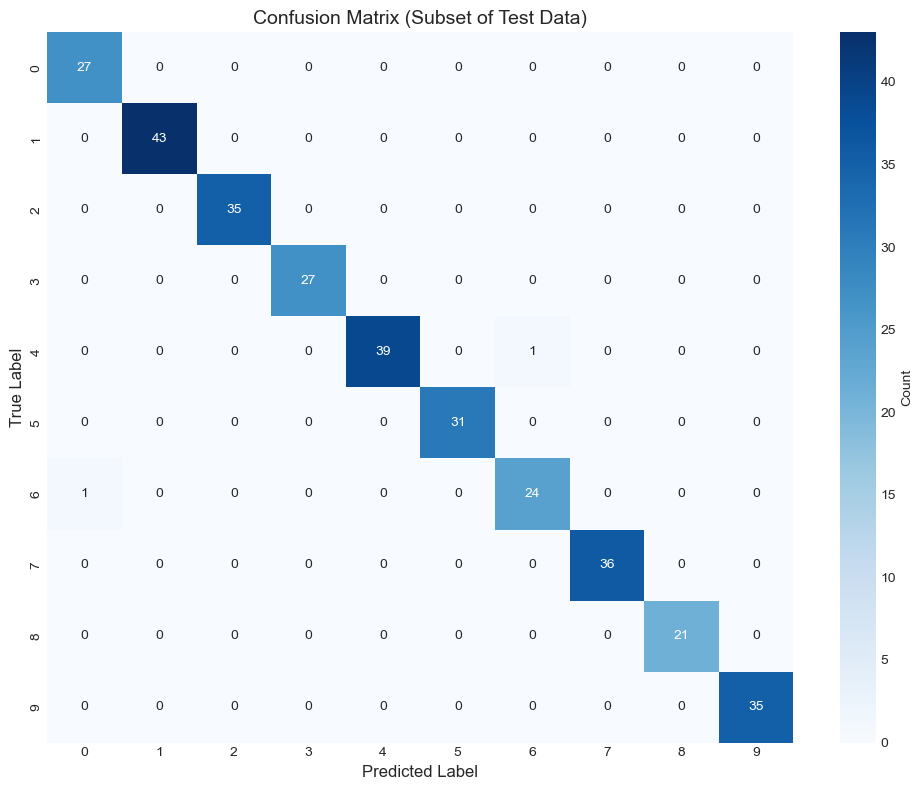

In [56]:
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    probabilities = F.softmax(outputs, dim=1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()
probabilities = probabilities.cpu()

for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(images[i].squeeze(), cmap='gray')
    
    color = 'green' if predicted[i] == labels[i] else 'red'
    axes[row, col].set_title(
        f'True: {labels[i]}, Pred: {predicted[i]}\nConfidence: {probabilities[i][predicted[i]]:.2f}',
        color=color,
        fontsize=9
    )
    axes[row, col].axis('off')

plt.suptitle('CNN Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in list(test_loader)[:5]:  
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Subset of Test Data)', fontsize=14)
plt.tight_layout()
plt.show()


## Summary

### Key Concepts Covered:

1. **Convolution Operation**: 
   - Filters detect features by sliding over the image
   - Different filters detect different features (edges, textures, etc.)
   - Reduces parameters through weight sharing

2. **Pooling Layers**:
   - Reduces spatial dimensions
   - Max pooling preserves strongest activations
   - Makes network translation-invariant

3. **Activation Functions**:
   - Introduce non-linearity (ReLU most common)
   - Enable learning complex patterns
   - Critical for deep networks

4. **Complete CNN Architecture**:
   - Multiple convolutional blocks extract hierarchical features
   - Fully connected layers perform final classification
   - Dropout prevents overfitting

### Why CNNs Work:

- **Local Connectivity**: Each neuron connects only to a local region
- **Parameter Sharing**: Same filter used across entire image
- **Translation Invariance**: Can detect features anywhere in the image
- **Hierarchical Learning**: Simple features → Complex patterns → Objects

### Next Steps:

- Experiment with different architectures (deeper networks, different filter sizes)
- Try on galaxy datasets
- Explore advanced techniques (batch normalization, residual connections)
- Study transfer learning (using pre-trained models)


Visualizing feature maps for digit: 7


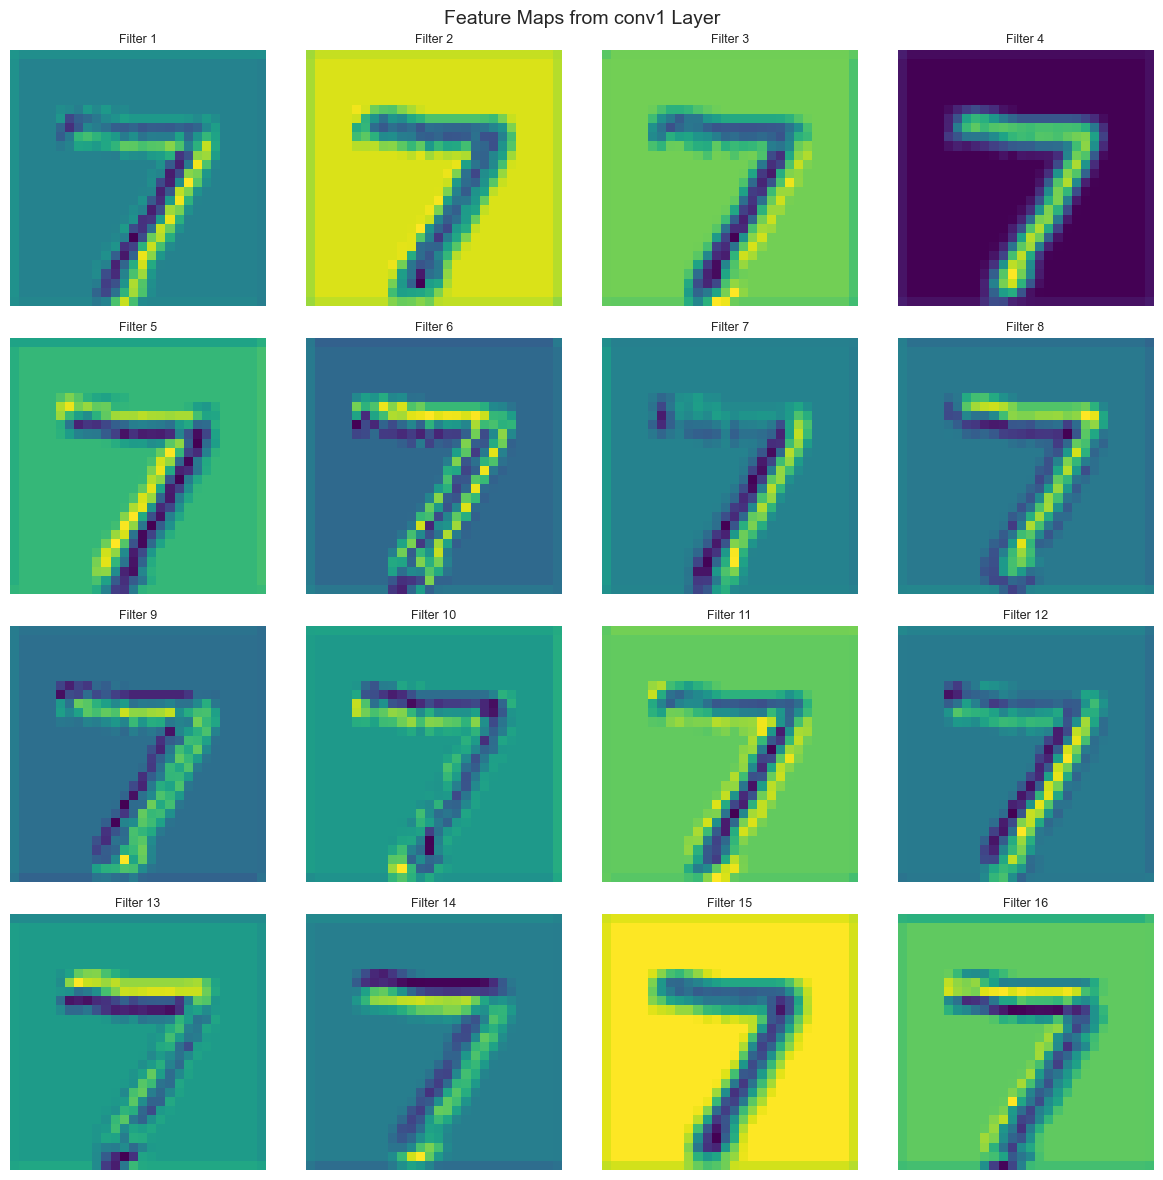


These feature maps show what patterns the CNN learned to detect!
Notice how different filters respond to different parts of the image.


In [ ]:
# Optional: Visualize learned filters (feature maps)
# This shows what the CNN learned to detect

def visualize_feature_maps(model, image, layer_name='conv1'):
    """
    Visualize feature maps from a specific layer
    """
    model.eval()
    
    if layer_name == 'conv1':
        layer = model.conv1
    elif layer_name == 'conv2':
        layer = model.conv2
    elif layer_name == 'conv3':
        layer = model.conv3
    else:
        raise ValueError("Invalid layer name")
    
    feature_maps = []
    def hook_fn(module, input, output):
        feature_maps.append(output)
    
    hook = layer.register_forward_hook(hook_fn)
    
    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(device))
    
    hook.remove()
    
    fm = feature_maps[0].squeeze().cpu().numpy()
    num_filters = fm.shape[0]
    
    n_filters_to_show = min(16, num_filters)
    cols = 4
    rows = (n_filters_to_show + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_filters_to_show):
        row, col = i // cols, i % cols
        axes[row, col].imshow(fm[i], cmap='viridis')
        axes[row, col].set_title(f'Filter {i+1}', fontsize=9)
        axes[row, col].axis('off')
    
    plt.suptitle(f'Feature Maps from {layer_name} Layer', fontsize=14)
    plt.tight_layout()
    plt.show()

sample_img, sample_label = test_dataset[0]
print(f"Visualizing feature maps for digit: {sample_label}")
visualize_feature_maps(model, sample_img, layer_name='conv1')

print("\nThese feature maps show what patterns the CNN learned to detect!")
print("Notice how different filters respond to different parts of the image.")